# Lab 4: Model Monitoring & Drift Detection

**Date:** February 2026  
**GCP Project:** carty-470812  
**Dataset:** Census Income (adult_income)  
**Best Accuracy:** 87.59% (Lab 3 Vertex AI tuning)  

---

## Overview

This lab explores what happens **after** you deploy a model. In production, models degrade over time
because the world changes but the model doesn't. This lab covers:

1. **Part 1: Retrain & Deploy** — Retrain model, deploy to endpoint
2. **Part 2: Enable Monitoring** — Set up Vertex AI Model Monitoring for skew & drift
3. **Part 3: Simulate & Detect Drift** — Create drifted data, send predictions, trigger alerts
4. **Part 4: Drift Analysis** — Measure degradation, identify which features drifted
5. **Part 5: Response Runbook** — Create production incident response procedures

### Key Concepts (Exam-Critical)

| Term | What It Means | Example |
|------|---------------|--------|
| **Training-serving skew** | Serving data differs from training data | Model trained on US data, deployed globally |
| **Data drift** | Input feature distributions change over time | Average age shifts from 38 to 48 |
| **Concept drift** | Relationship between features and target changes | Education no longer predicts income the same way |
| **Prediction drift** | Model output distribution changes | Model starts predicting >50K more often |

---

## Part 1: Retrain & Deploy

We need a live endpoint to monitor. Since you deleted the model from Lab 2/3,
we'll retrain using your best hyperparameters from Lab 3 and redeploy.

**Reusing your Lab 2 infrastructure:**
- Same container: `us-central1-docker.pkg.dev/carty-470812/ml-containers/census-sklearn:latest`
- Same training script (`lab2_custom_train.py` → `train.py` in container)
- Same serving script (`serve.py` with Flask)
- Best hyperparameters from Lab 3

In [1]:
# Install required packages
!pip install google-cloud-aiplatform pandas numpy scikit-learn matplotlib seaborn scipy -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from google.cloud import aiplatform
from datetime import datetime
import pandas as pd
import numpy as np
import time

# Project configuration
PROJECT_ID = 'carty-470812'
REGION = 'us-central1'
BUCKET_NAME = 'carty-470812-ml-census-data'
DATA_PATH = f'gs://{BUCKET_NAME}/data/census_income.csv'
CUSTOM_IMAGE = f'us-central1-docker.pkg.dev/{PROJECT_ID}/ml-containers/census-sklearn:latest'

TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

# Initialize Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=f'gs://{BUCKET_NAME}/staging'
)

print(f"Configuration:")
print(f"  Project: {PROJECT_ID}")
print(f"  Region: {REGION}")
print(f"  Data: {DATA_PATH}")
print(f"  Container: {CUSTOM_IMAGE}")
print(f"  Timestamp: {TIMESTAMP}")
print(f"\nVertex AI initialized")

Configuration:
  Project: carty-470812
  Region: us-central1
  Data: gs://carty-470812-ml-census-data/data/census_income.csv
  Container: us-central1-docker.pkg.dev/carty-470812/ml-containers/census-sklearn:latest
  Timestamp: 20260221_164359

Vertex AI initialized


### Step 1: Retrain Model

Using best hyperparameters from Lab 3 (87.59% accuracy).

**Update these values if your Lab 3 results were different:**

In [3]:
# Best hyperparameters from Lab 3 Vertex AI tuning
BEST_N_ESTIMATORS = '385'
BEST_MAX_DEPTH = '8'
BEST_LEARNING_RATE = '0.027738'
BEST_MIN_SAMPLES_SPLIT = '7'  

print("Best hyperparameters from Lab 3:")
print(f"  n_estimators: {BEST_N_ESTIMATORS}")
print(f"  max_depth: {BEST_MAX_DEPTH}")
print(f"  learning_rate: {BEST_LEARNING_RATE}")
print(f"  min_samples_split: {BEST_MIN_SAMPLES_SPLIT}")

Best hyperparameters from Lab 3:
  n_estimators: 385
  max_depth: 8
  learning_rate: 0.027738
  min_samples_split: 7


In [4]:
# Define training job (same pattern as Lab 2)
job = aiplatform.CustomContainerTrainingJob(
    display_name=f'census-lab4-{TIMESTAMP}',
    container_uri=CUSTOM_IMAGE,
    model_serving_container_image_uri=CUSTOM_IMAGE,
    model_serving_container_command=['python', 'serve.py'],
    model_serving_container_predict_route='/predict',
    model_serving_container_health_route='/health',
    model_serving_container_ports=[8080],
)

print("Training job defined")
print(f"  Same container for training AND serving")

Training job defined
  Same container for training AND serving


In [5]:
print("Starting training job...")
print(f"  Console: https://console.cloud.google.com/vertex-ai/training/custom-jobs?project={PROJECT_ID}")
print(f"  Expected duration: ~10-15 minutes")

model = job.run(
    args=[
        '--data-path', DATA_PATH,
        '--target-column', 'income_bracket',
        '--n-estimators', BEST_N_ESTIMATORS,
        '--max-depth', BEST_MAX_DEPTH,
        '--learning-rate', BEST_LEARNING_RATE,
        '--min-samples-split', BEST_MIN_SAMPLES_SPLIT,
    ],
    replica_count=1,
    machine_type='n1-standard-4',
    base_output_dir=f'gs://{BUCKET_NAME}/models/census-lab4-{TIMESTAMP}/',
    model_display_name=f'census-lab4-model-{TIMESTAMP}',
    sync=True,
)

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

Starting training job...
  Console: https://console.cloud.google.com/vertex-ai/training/custom-jobs?project=carty-470812
  Expected duration: ~10-15 minutes
Training Output directory:
gs://carty-470812-ml-census-data/models/census-lab4-20260221_164359/ 
View Training:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/5797158478875197440?project=873708835509
View backing custom job:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/2735858622402658304?project=873708835509
CustomContainerTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/5797158478875197440 current state:
3
CustomContainerTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/5797158478875197440 current state:
3
CustomContainerTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/5797158478875197440 current state:
3
CustomContainerTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/57971

### Step 2: Deploy Model to Endpoint

**Cost:** ~$0.10/hour for n1-standard-2. Keep it running for this lab, then undeploy.

**Expected duration:** 5-10 minutes

In [6]:
# If model variable was lost (e.g., kernel restart), retrieve it:
# models = aiplatform.Model.list(order_by="create_time desc")
# model = models[0]
# print(f"Found model: {model.display_name}")

print("Deploying model to endpoint...")
print("This takes 5-10 minutes...")

endpoint = model.deploy(
    deployed_model_display_name=f'census-lab4-deployed-{TIMESTAMP}',
    machine_type='n1-standard-2',
    min_replica_count=1,
    max_replica_count=1,  # Keep at 1 for cost control
    traffic_percentage=100,
    sync=True,
)

print("\n" + "="*60)
print("MODEL DEPLOYED!")
print("="*60)
print(f"  Endpoint: {endpoint.display_name}")
print(f"  Resource: {endpoint.resource_name}")
print(f"\n  Cost: ~$0.10/hour while running")
print(f"  Remember to undeploy when done!")

Deploying model to endpoint...
This takes 5-10 minutes...
Creating Endpoint
Create Endpoint backing LRO: projects/873708835509/locations/us-central1/endpoints/7728457336032854016/operations/1172025802607296512
Endpoint created. Resource name: projects/873708835509/locations/us-central1/endpoints/7728457336032854016
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/873708835509/locations/us-central1/endpoints/7728457336032854016')
Deploying model to Endpoint : projects/873708835509/locations/us-central1/endpoints/7728457336032854016
Deploy Endpoint model backing LRO: projects/873708835509/locations/us-central1/endpoints/7728457336032854016/operations/3813949934013513728
Endpoint model deployed. Resource name: projects/873708835509/locations/us-central1/endpoints/7728457336032854016

MODEL DEPLOYED!
  Endpoint: census-lab4-model-20260221_164359_endpoint
  Resource: projects/873708835509/locations/us-central1/endpoints/7728457336032854016

  Cost: ~$0.10/ho

In [7]:
# Quick sanity check - test a prediction
test_instance = {
    'age': 39, 'workclass': 'Private', 'functional_weight': 77516,
    'education': 'Bachelors', 'education_num': 13,
    'marital_status': 'Never-married', 'occupation': 'Tech-support',
    'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Male',
    'capital_gain': 2174, 'capital_loss': 0,
    'hours_per_week': 40, 'native_country': 'United-States'
}

prediction = endpoint.predict(instances=[test_instance])
pred_class = '>50K' if prediction.predictions[0] == 1 else '<=50K'
print(f"Test prediction: {pred_class} (raw: {prediction.predictions[0]})")
print("Endpoint is working!")

Test prediction: <=50K (raw: 0.0)
Endpoint is working!


---

## Part 2: Understanding Model Monitoring

### What Vertex AI Model Monitoring Does

Vertex AI Model Monitoring watches your deployed model and detects:

1. **Training-serving skew** — Are prediction inputs different from training data?
2. **Prediction drift** — Are model outputs changing over time?
3. **Feature drift** — Are individual feature distributions shifting?

It uses statistical distance measures (Jensen-Shannon divergence for categorical features,
L-infinity distance for numerical features) to quantify how much distributions have changed.

### Important Practical Note

Vertex AI Model Monitoring requires:
- Logging enabled on the endpoint (predictions get logged to BigQuery)
- Enough prediction volume for statistical significance
- Time for the monitoring job to run (typically runs on a schedule, e.g., hourly/daily)

**For this lab**, we'll do two things in parallel:
1. Set up Vertex AI Model Monitoring (real GCP service)
2. Run our own drift analysis locally (immediate results, deeper understanding)

This mirrors real production work — you don't just rely on automated alerts,
you also build dashboards and ad-hoc analysis capabilities.

### Step 1: Enable Prediction Logging

Before monitoring can work, we need predictions to be logged.
Vertex AI can log prediction requests/responses to a BigQuery table.

In [8]:
# Note: Vertex AI Model Monitoring v2 (current) handles logging automatically
# when you create a monitoring job. For v1, you'd need to enable request-response
# logging separately.
#
# Let's check the endpoint's deployed model ID (needed for monitoring config)

deployed_models = endpoint.gca_resource.deployed_models
if deployed_models:
    deployed_model_id = deployed_models[0].id
    print(f"Deployed model ID: {deployed_model_id}")
    print(f"Model display name: {deployed_models[0].display_name}")
else:
    print("ERROR: No models deployed on this endpoint!")
    print("Go back to Step 2 and deploy first.")

Deployed model ID: 1389871208194899968
Model display name: census-lab4-deployed-20260221_164359


### Step 2: Create Model Monitoring Job

This configures Vertex AI to watch for drift and skew.

**Key parameters:**
- `skew_thresholds`: How different can serving data be from training data?
- `drift_thresholds`: How much can serving data change over time?
- `monitor_interval`: How often to check (in seconds)
- `sample_rate`: What fraction of predictions to log

In [9]:
from google.cloud.aiplatform_v1beta1 import (
    JobServiceClient,
    ModelDeploymentMonitoringJob,
    ModelDeploymentMonitoringObjectiveConfig,
    ModelDeploymentMonitoringScheduleConfig,
    ModelMonitoringObjectiveConfig,
    SamplingStrategy,
    ThresholdConfig,
)
from google.protobuf.duration_pb2 import Duration

# Define monitoring thresholds
# These are Jensen-Shannon divergence thresholds (0 = identical, 1 = completely different)
# Lower threshold = more sensitive = more alerts

# Features we want to monitor closely
SKEW_THRESHOLDS = {
    'age': ThresholdConfig(value=0.1),
    'hours_per_week': ThresholdConfig(value=0.1),
    'education_num': ThresholdConfig(value=0.1),
    'capital_gain': ThresholdConfig(value=0.15),
}

DRIFT_THRESHOLDS = {
    'age': ThresholdConfig(value=0.1),
    'hours_per_week': ThresholdConfig(value=0.1),
    'education_num': ThresholdConfig(value=0.1),
    'capital_gain': ThresholdConfig(value=0.15),
}

print("Monitoring thresholds defined:")
for feature, threshold in SKEW_THRESHOLDS.items():
    print(f"  {feature}: skew={threshold.value}, drift={DRIFT_THRESHOLDS[feature].value}")

Monitoring thresholds defined:
  age: skew=0.1, drift=0.1
  hours_per_week: skew=0.1, drift=0.1
  education_num: skew=0.1, drift=0.1
  capital_gain: skew=0.15, drift=0.15


In [11]:
# Create the monitoring job

from google.cloud.aiplatform_v1beta1 import (
    JobServiceClient,
    ModelDeploymentMonitoringJob,
    ModelDeploymentMonitoringObjectiveConfig,
    ModelDeploymentMonitoringScheduleConfig,
    ModelMonitoringObjectiveConfig,
    SamplingStrategy,
    ThresholdConfig,
)
from google.cloud.aiplatform_v1beta1.types import GcsSource
from google.protobuf.duration_pb2 import Duration

API_ENDPOINT = f'{REGION}-aiplatform.googleapis.com'
client = JobServiceClient(client_options={'api_endpoint': API_ENDPOINT})

objective_config = ModelDeploymentMonitoringObjectiveConfig(
    deployed_model_id=deployed_model_id,
    objective_config=ModelMonitoringObjectiveConfig(
        training_dataset=ModelMonitoringObjectiveConfig.TrainingDataset(
            gcs_source=GcsSource(uris=[DATA_PATH]),
            data_format='csv',
            target_field='income_bracket',
        ),
        training_prediction_skew_detection_config=ModelMonitoringObjectiveConfig.TrainingPredictionSkewDetectionConfig(
            skew_thresholds=SKEW_THRESHOLDS,
        ),
        prediction_drift_detection_config=ModelMonitoringObjectiveConfig.PredictionDriftDetectionConfig(
            drift_thresholds=DRIFT_THRESHOLDS,
        ),
    ),
)

monitoring_job = ModelDeploymentMonitoringJob(
    display_name=f'census-monitoring-{TIMESTAMP}',
    endpoint=endpoint.resource_name,
    model_deployment_monitoring_objective_configs=[objective_config],
    logging_sampling_strategy=SamplingStrategy(
        random_sample_config=SamplingStrategy.RandomSampleConfig(
            sample_rate=0.8
        )
    ),
    model_deployment_monitoring_schedule_config=ModelDeploymentMonitoringScheduleConfig(
        monitor_interval=Duration(seconds=3600),
    ),
)

PARENT = f'projects/{PROJECT_ID}/locations/{REGION}'

print("Creating monitoring job...")
response = client.create_model_deployment_monitoring_job(
    parent=PARENT,
    model_deployment_monitoring_job=monitoring_job,
)

print(f"\nMonitoring job created!")
print(f"  Name: {response.name}")
print(f"  State: {response.state}")
print(f"  Console: https://console.cloud.google.com/vertex-ai/models/monitoring?project={PROJECT_ID}")

MONITORING_JOB_NAME = response.name

Creating monitoring job...

Monitoring job created!
  Name: projects/873708835509/locations/us-central1/modelDeploymentMonitoringJobs/2385611392397869056
  State: 2
  Console: https://console.cloud.google.com/vertex-ai/models/monitoring?project=carty-470812


### Monitoring Job Notes

The monitoring job is now running in the background. It will:
1. Sample 80% of incoming predictions
2. Every hour, compare the logged predictions against the training data baseline
3. If any feature's distribution exceeds the threshold, flag an anomaly

**While we wait for it to collect data, let's do our own drift analysis locally.**
This is actually more educational and gives immediate results.

---

## Part 3: Simulate & Detect Drift (Local Analysis)

### The Scenario

Imagine it's 2035. Your model was trained on 1994 census data. The world has changed:
- Population is older (retirement age increased)
- People work more hours (gig economy, remote work)
- Education levels increased
- Income thresholds shifted due to inflation

We'll simulate these changes and measure the impact on model performance.

In [13]:
# Load the original training data
print("Loading original data...")
df = pd.read_csv('../lab2/census_income.csv')  # Use local copy, or download from GCS:
# from google.cloud import storage
# storage_client = storage.Client(project=PROJECT_ID)
# bucket = storage_client.bucket(BUCKET_NAME)
# bucket.blob('data/census_income.csv').download_to_filename('census_income.csv')
# df = pd.read_csv('census_income.csv')

print(f"Loaded {len(df):,} rows")
print(f"\nOriginal data summary (key numeric features):")
print(df[['age', 'hours_per_week', 'education_num', 'capital_gain']].describe().round(2))

Loading original data...
Loaded 32,561 rows

Original data summary (key numeric features):
            age  hours_per_week  education_num  capital_gain
count  32561.00        32561.00       32561.00      32561.00
mean      38.58           40.44          10.08       1077.65
std       13.64           12.35           2.57       7385.29
min       17.00            1.00           1.00          0.00
25%       28.00           40.00           9.00          0.00
50%       37.00           40.00          10.00          0.00
75%       48.00           45.00          12.00          0.00
max       90.00           99.00          16.00      99999.00


In [14]:
# Separate features and target (same preprocessing as training script)
X_original = df.drop(columns=['income_bracket'])
y_original = df['income_bracket'].str.strip().str.replace('.', '', regex=False)
y_original = (y_original == '>50K').astype(int)

print(f"Features: {X_original.shape}")
print(f"Target distribution: {y_original.value_counts().to_dict()}")
print(f"  <=50K: {(y_original == 0).sum():,} ({(y_original == 0).mean()*100:.1f}%)")
print(f"  >50K: {(y_original == 1).sum():,} ({(y_original == 1).mean()*100:.1f}%)")

Features: (32561, 14)
Target distribution: {0: 24720, 1: 7841}
  <=50K: 24,720 (75.9%)
  >50K: 7,841 (24.1%)


### Create Drifted Datasets

We'll create three drift scenarios of increasing severity:

In [15]:
def create_drifted_data(df, scenario):
    """
    Create drifted versions of the dataset.
    
    Each scenario simulates realistic ways data distributions change over time.
    We modify FEATURES but keep LABELS the same — this simulates data drift
    (not concept drift). The model's accuracy will degrade because the
    feature-target relationship it learned no longer holds for the shifted data.
    """
    drifted = df.copy()
    changes = []
    
    if scenario == 'mild':
        # Mild drift: slight demographic shift
        drifted['age'] = drifted['age'] + 3
        drifted['hours_per_week'] = (drifted['hours_per_week'] * 1.05).clip(1, 99)
        changes = ['age +3 years', 'hours_per_week +5%']
        
    elif scenario == 'moderate':
        # Moderate drift: noticeable population change
        drifted['age'] = drifted['age'] + 10
        drifted['hours_per_week'] = (drifted['hours_per_week'] * 1.2).clip(1, 99)
        drifted['education_num'] = (drifted['education_num'] + 2).clip(1, 16)
        changes = ['age +10 years', 'hours_per_week +20%', 'education_num +2']
        
    elif scenario == 'severe':
        # Severe drift: major socioeconomic shift
        drifted['age'] = drifted['age'] + 15
        drifted['hours_per_week'] = (drifted['hours_per_week'] * 1.4).clip(1, 99)
        drifted['education_num'] = (drifted['education_num'] + 4).clip(1, 16)
        drifted['capital_gain'] = (drifted['capital_gain'] * 2.0).astype(int)
        changes = ['age +15 years', 'hours_per_week +40%', 'education_num +4', 'capital_gain 2x']
        
    else:
        raise ValueError(f"Unknown scenario: {scenario}")
    
    return drifted, changes

# Create all three scenarios
df_mild, mild_changes = create_drifted_data(df, 'mild')
df_moderate, moderate_changes = create_drifted_data(df, 'moderate')
df_severe, severe_changes = create_drifted_data(df, 'severe')

print("Drift scenarios created:")
print(f"\n  Mild:     {mild_changes}")
print(f"  Moderate: {moderate_changes}")
print(f"  Severe:   {severe_changes}")

Drift scenarios created:

  Mild:     ['age +3 years', 'hours_per_week +5%']
  Moderate: ['age +10 years', 'hours_per_week +20%', 'education_num +2']
  Severe:   ['age +15 years', 'hours_per_week +40%', 'education_num +4', 'capital_gain 2x']


In [16]:
# Compare distributions
print("FEATURE DISTRIBUTION COMPARISON")
print("=" * 80)

for feature in ['age', 'hours_per_week', 'education_num', 'capital_gain']:
    print(f"\n{feature}:")
    print(f"  {'':>12} {'Mean':>8} {'Std':>8} {'Median':>8}")
    print(f"  {'Original':>12} {df[feature].mean():>8.2f} {df[feature].std():>8.2f} {df[feature].median():>8.1f}")
    print(f"  {'Mild':>12} {df_mild[feature].mean():>8.2f} {df_mild[feature].std():>8.2f} {df_mild[feature].median():>8.1f}")
    print(f"  {'Moderate':>12} {df_moderate[feature].mean():>8.2f} {df_moderate[feature].std():>8.2f} {df_moderate[feature].median():>8.1f}")
    print(f"  {'Severe':>12} {df_severe[feature].mean():>8.2f} {df_severe[feature].std():>8.2f} {df_severe[feature].median():>8.1f}")

FEATURE DISTRIBUTION COMPARISON

age:
                   Mean      Std   Median
      Original    38.58    13.64     37.0
          Mild    41.58    13.64     40.0
      Moderate    48.58    13.64     47.0
        Severe    53.58    13.64     52.0

hours_per_week:
                   Mean      Std   Median
      Original    40.44    12.35     40.0
          Mild    42.44    12.90     42.0
      Moderate    48.45    14.51     48.0
        Severe    56.34    16.39     56.0

education_num:
                   Mean      Std   Median
      Original    10.08     2.57     10.0
          Mild    10.08     2.57     10.0
      Moderate    12.04     2.49     12.0
        Severe    13.71     2.07     14.0

capital_gain:
                   Mean      Std   Median
      Original  1077.65  7385.29      0.0
          Mild  1077.65  7385.29      0.0
      Moderate  1077.65  7385.29      0.0
        Severe  2155.30 14770.58      0.0


### Send Drifted Predictions to Endpoint

We'll send predictions from each scenario through the live endpoint.
This serves two purposes:
1. Feed data to Vertex AI Model Monitoring so it can detect drift
2. Collect predictions for our local analysis

In [29]:
def send_predictions(endpoint, data, n_samples=200, scenario_name='unknown'):
    """
    Send prediction requests to the endpoint.
    Returns predictions for analysis.
    
    We send in batches to be efficient (Vertex AI supports batch online predictions).
    """
    features = data.drop(columns=['income_bracket'])
    
    # Sample rows for predictions
    sample = features.sample(n=min(n_samples, len(features)), random_state=42)
    
    all_predictions = []
    batch_size = 50  # Send 50 at a time
    
    print(f"Sending {len(sample)} {scenario_name} predictions...")
    
    for i in range(0, len(sample), batch_size):
        batch = sample.iloc[i:i+batch_size]
        instances = batch.to_dict('records')
        
        try:
            response = endpoint.predict(instances=instances)
            all_predictions.extend(response.predictions)
        except Exception as e:
            print(f"  Error at batch {i}: {e}")
            continue
        
        # Small delay to simulate realistic traffic
        time.sleep(0.5)
    
    print(f"  Received {len(all_predictions)} predictions")
    return all_predictions, sample.index.tolist()

# Send predictions for each scenario
print("Sending predictions through live endpoint...")
print("(This feeds data to Vertex AI Model Monitoring AND collects results for our analysis)")
print()

# Original data (baseline)
preds_original, idx_original = send_predictions(endpoint, df, n_samples=200, scenario_name='original')

# Drifted scenarios
preds_mild, idx_mild = send_predictions(endpoint, df_mild, n_samples=200, scenario_name='mild')
preds_moderate, idx_moderate = send_predictions(endpoint, df_moderate, n_samples=200, scenario_name='moderate')
preds_severe, idx_severe = send_predictions(endpoint, df_severe, n_samples=200, scenario_name='severe')

print(f"\nTotal predictions sent: {len(preds_original) + len(preds_mild) + len(preds_moderate) + len(preds_severe)}")
print("Vertex AI Monitoring will analyze these in its next monitoring run.")

Sending predictions through live endpoint...
(This feeds data to Vertex AI Model Monitoring AND collects results for our analysis)

Sending 200 original predictions...
  Received 200 predictions
Sending 200 mild predictions...
  Received 200 predictions
Sending 200 moderate predictions...
  Received 200 predictions
Sending 200 severe predictions...
  Received 200 predictions

Total predictions sent: 800
Vertex AI Monitoring will analyze these in its next monitoring run.


---

## Part 4: Drift Analysis

Now let's measure the impact of drift. We have two things to analyze:
1. **Statistical drift** — How much did feature distributions change? (using statistical tests)
2. **Performance degradation** — How much did accuracy drop? (using actual labels)

### 4.1: Measure Performance Degradation

Since we have the true labels, we can calculate exact accuracy for each scenario.

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def get_actual_labels(df, indices):
    """Get true labels for the sampled indices."""
    y = df['income_bracket'].str.strip().str.replace('.', '', regex=False)
    y = (y == '>50K').astype(int)
    return y.iloc[indices].values

# Get true labels for each scenario
# NOTE: For drifted data, labels come from the ORIGINAL data (same rows, just features changed)
# This is realistic — the true relationship hasn't changed, but the inputs have
y_true_original = get_actual_labels(df, idx_original)
y_true_mild = get_actual_labels(df, idx_mild)       # Same people, shifted features
y_true_moderate = get_actual_labels(df, idx_moderate)
y_true_severe = get_actual_labels(df, idx_severe)

# Convert predictions to arrays
pred_arrays = {
    'Original': (np.array(preds_original), y_true_original),
    'Mild drift': (np.array(preds_mild), y_true_mild),
    'Moderate drift': (np.array(preds_moderate), y_true_moderate),
    'Severe drift': (np.array(preds_severe), y_true_severe),
}

# Calculate accuracy for each
print("PERFORMANCE DEGRADATION ANALYSIS")
print("=" * 70)
print(f"{'Scenario':<20} {'Accuracy':>10} {'Pred >50K %':>15} {'Degradation':>15}")
print("-" * 70)

baseline_acc = None
results = []

for scenario, (preds, y_true) in pred_arrays.items():
    acc = accuracy_score(y_true, preds)
    pct_positive = (preds == 1).mean() * 100
    
    if baseline_acc is None:
        baseline_acc = acc
        degradation = 'baseline'
    else:
        degradation = f'{(acc - baseline_acc)*100:+.2f}pp'
    
    results.append({'scenario': scenario, 'accuracy': acc, 'pct_positive': pct_positive})
    print(f"{scenario:<20} {acc*100:>9.2f}% {pct_positive:>14.1f}% {degradation:>15}")

print("=" * 70)
print(f"\nKey insight: As drift increases, accuracy degrades AND prediction")
print(f"distribution shifts (more >50K predictions with older, higher-educated population).")

PERFORMANCE DEGRADATION ANALYSIS
Scenario               Accuracy     Pred >50K %     Degradation
----------------------------------------------------------------------
Original                 87.50%           25.5%        baseline
Mild drift               87.00%           26.0%         -0.50pp
Moderate drift           84.00%           33.0%         -3.50pp
Severe drift             80.00%           44.0%         -7.50pp

Key insight: As drift increases, accuracy degrades AND prediction
distribution shifts (more >50K predictions with older, higher-educated population).


### 4.2: Statistical Drift Detection

Now let's use proper statistical tests to measure drift — the same idea Vertex AI uses internally.

**Key tests:**
- **Kolmogorov-Smirnov (KS) test** — Measures the maximum difference between two distributions (for numeric features)
- **Jensen-Shannon (JS) divergence** — Symmetric measure of distribution difference (what Vertex AI uses)
- **Population Stability Index (PSI)** — Industry-standard metric for drift detection

In [19]:
from scipy import stats
from scipy.spatial.distance import jensenshannon

def calculate_drift_metrics(original, drifted, feature, n_bins=50):
    """
    Calculate multiple drift metrics for a numeric feature.
    
    Returns:
        ks_stat: Kolmogorov-Smirnov statistic (0-1, higher = more drift)
        ks_pvalue: KS test p-value (low = statistically significant drift)
        js_divergence: Jensen-Shannon divergence (0-1, higher = more drift)
        psi: Population Stability Index (>0.2 = significant drift)
    """
    orig = original[feature].values
    drift = drifted[feature].values
    
    # 1. KS Test
    ks_stat, ks_pvalue = stats.ks_2samp(orig, drift)
    
    # 2. Jensen-Shannon Divergence
    # Need to create histograms first (same bins for both)
    min_val = min(orig.min(), drift.min())
    max_val = max(orig.max(), drift.max())
    bins = np.linspace(min_val, max_val, n_bins + 1)
    
    hist_orig, _ = np.histogram(orig, bins=bins, density=True)
    hist_drift, _ = np.histogram(drift, bins=bins, density=True)
    
    # Add small epsilon to avoid division by zero
    hist_orig = hist_orig + 1e-10
    hist_drift = hist_drift + 1e-10
    
    # Normalize to probability distributions
    hist_orig = hist_orig / hist_orig.sum()
    hist_drift = hist_drift / hist_drift.sum()
    
    js_div = jensenshannon(hist_orig, hist_drift)
    
    # 3. PSI (Population Stability Index)
    # PSI = sum((actual% - expected%) * ln(actual%/expected%))
    psi = np.sum((hist_drift - hist_orig) * np.log(hist_drift / hist_orig))
    
    return {
        'ks_stat': ks_stat,
        'ks_pvalue': ks_pvalue,
        'js_divergence': js_div,
        'psi': psi,
    }

# Calculate drift metrics for all numeric features across all scenarios
numeric_features = ['age', 'hours_per_week', 'education_num', 'capital_gain', 'capital_loss']

drift_results = []
for scenario_name, drifted_df in [('Mild', df_mild), ('Moderate', df_moderate), ('Severe', df_severe)]:
    for feature in numeric_features:
        metrics = calculate_drift_metrics(df, drifted_df, feature)
        drift_results.append({
            'scenario': scenario_name,
            'feature': feature,
            **metrics
        })

drift_df = pd.DataFrame(drift_results)
print("Drift metrics calculated for all features and scenarios")

Drift metrics calculated for all features and scenarios


In [20]:
# Display drift results
print("STATISTICAL DRIFT ANALYSIS")
print("=" * 90)
print(f"{'Scenario':<12} {'Feature':<18} {'KS Stat':>8} {'KS p-val':>10} {'JS Div':>8} {'PSI':>8} {'Alert?':>8}")
print("-" * 90)

for _, row in drift_df.iterrows():
    # PSI thresholds: <0.1 = no drift, 0.1-0.2 = moderate, >0.2 = significant
    alert = 'YES' if row['psi'] > 0.1 else 'no'
    if row['psi'] > 0.2:
        alert = 'SEVERE'
    
    print(f"{row['scenario']:<12} {row['feature']:<18} {row['ks_stat']:>8.4f} {row['ks_pvalue']:>10.2e} "
          f"{row['js_divergence']:>8.4f} {row['psi']:>8.4f} {alert:>8}")

print("=" * 90)
print(f"\nPSI Interpretation:")
print(f"  < 0.1:  No significant drift")
print(f"  0.1-0.2: Moderate drift (monitor closely)")
print(f"  > 0.2:  Significant drift (consider retraining)")

STATISTICAL DRIFT ANALYSIS
Scenario     Feature             KS Stat   KS p-val   JS Div      PSI   Alert?
------------------------------------------------------------------------------------------
Mild         age                  0.0817   5.86e-95   0.1378   0.6462   SEVERE
Mild         hours_per_week       0.4685   0.00e+00   0.6524   4.9140   SEVERE
Mild         education_num        0.0000   1.00e+00   0.0000   0.0000       no
Mild         capital_gain         0.0000   1.00e+00   0.0000   0.0000       no
Mild         capital_loss         0.0000   1.00e+00   0.0000   0.0000       no
Moderate     age                  0.2657   0.00e+00   0.3221   4.5265   SEVERE
Moderate     hours_per_week       0.5581   0.00e+00   0.6124   4.2966   SEVERE
Moderate     education_num        0.5464   0.00e+00   0.5503   2.9883   SEVERE
Moderate     capital_gain         0.0000   1.00e+00   0.0000   0.0000       no
Moderate     capital_loss         0.0000   1.00e+00   0.0000   0.0000       no
Severe       

### 4.3: Visualize Drift

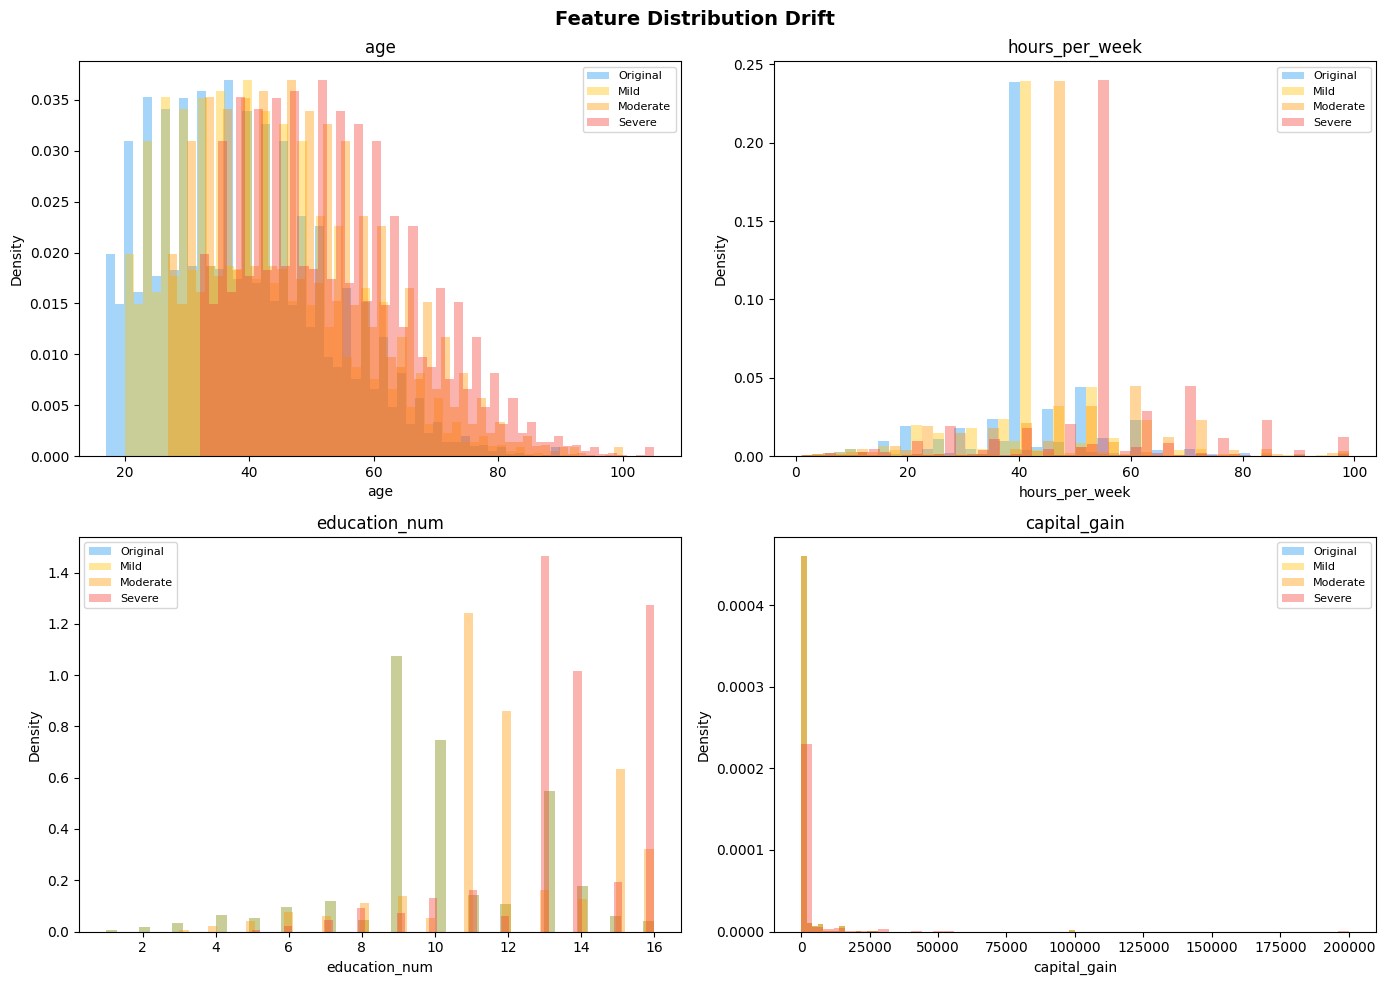

Saved: drift_distributions.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution Drift', fontsize=14, fontweight='bold')

features_to_plot = ['age', 'hours_per_week', 'education_num', 'capital_gain']
colors = {'Original': '#2196F3', 'Mild': '#FFC107', 'Moderate': '#FF9800', 'Severe': '#F44336'}

for idx, (feature, ax) in enumerate(zip(features_to_plot, axes.flat)):
    # Plot distributions
    for label, data, color in [
        ('Original', df, colors['Original']),
        ('Mild', df_mild, colors['Mild']),
        ('Moderate', df_moderate, colors['Moderate']),
        ('Severe', df_severe, colors['Severe']),
    ]:
        ax.hist(data[feature], bins=50, alpha=0.4, label=label, color=color, density=True)
    
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: drift_distributions.png")

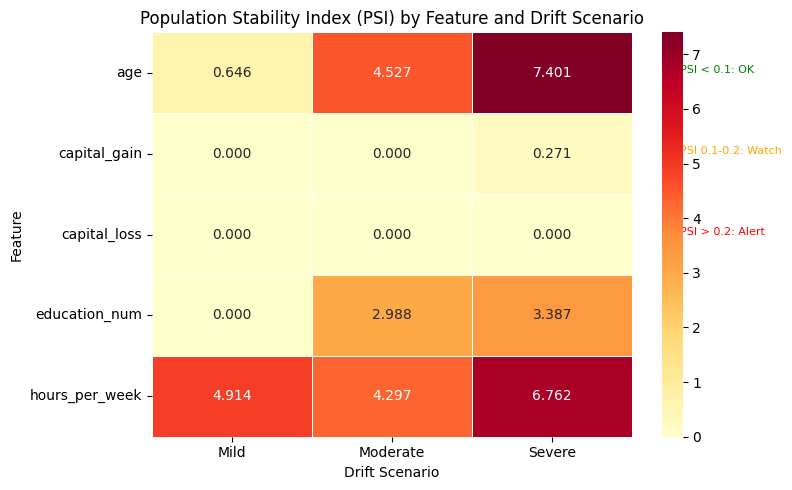

Saved: drift_psi_heatmap.png


In [22]:
# Heatmap: PSI values by feature and scenario
psi_pivot = drift_df.pivot(index='feature', columns='scenario', values='psi')
psi_pivot = psi_pivot[['Mild', 'Moderate', 'Severe']]  # Order columns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    psi_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
    vmin=0, vmax=max(0.5, psi_pivot.max().max()),
    linewidths=0.5, ax=ax
)
ax.set_title('Population Stability Index (PSI) by Feature and Drift Scenario')
ax.set_ylabel('Feature')
ax.set_xlabel('Drift Scenario')

# Add threshold lines annotation
ax.text(3.3, 0.5, 'PSI < 0.1: OK', fontsize=8, color='green')
ax.text(3.3, 1.5, 'PSI 0.1-0.2: Watch', fontsize=8, color='orange')
ax.text(3.3, 2.5, 'PSI > 0.2: Alert', fontsize=8, color='red')

plt.tight_layout()
plt.savefig('drift_psi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: drift_psi_heatmap.png")

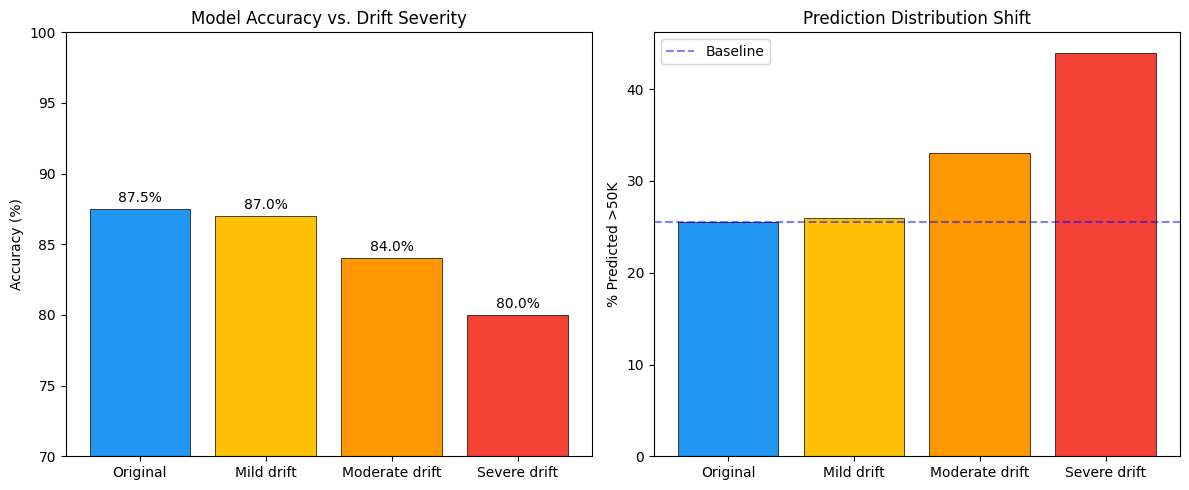

Saved: drift_accuracy_impact.png


In [23]:
# Accuracy degradation chart
results_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy by scenario
bar_colors = [colors['Original'], colors['Mild'], colors['Moderate'], colors['Severe']]
bars = ax1.bar(results_df['scenario'], results_df['accuracy'] * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Accuracy vs. Drift Severity')
ax1.set_ylim(min(results_df['accuracy'].min() * 100 - 5, 70), 100)

# Add value labels on bars
for bar, acc in zip(bars, results_df['accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10)

# Prediction distribution shift
ax2.bar(results_df['scenario'], results_df['pct_positive'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=results_df.iloc[0]['pct_positive'], color='blue', linestyle='--', alpha=0.5, label='Baseline')
ax2.set_ylabel('% Predicted >50K')
ax2.set_title('Prediction Distribution Shift')
ax2.legend()

plt.tight_layout()
plt.savefig('drift_accuracy_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: drift_accuracy_impact.png")

### 4.4: Confusion Matrix Comparison

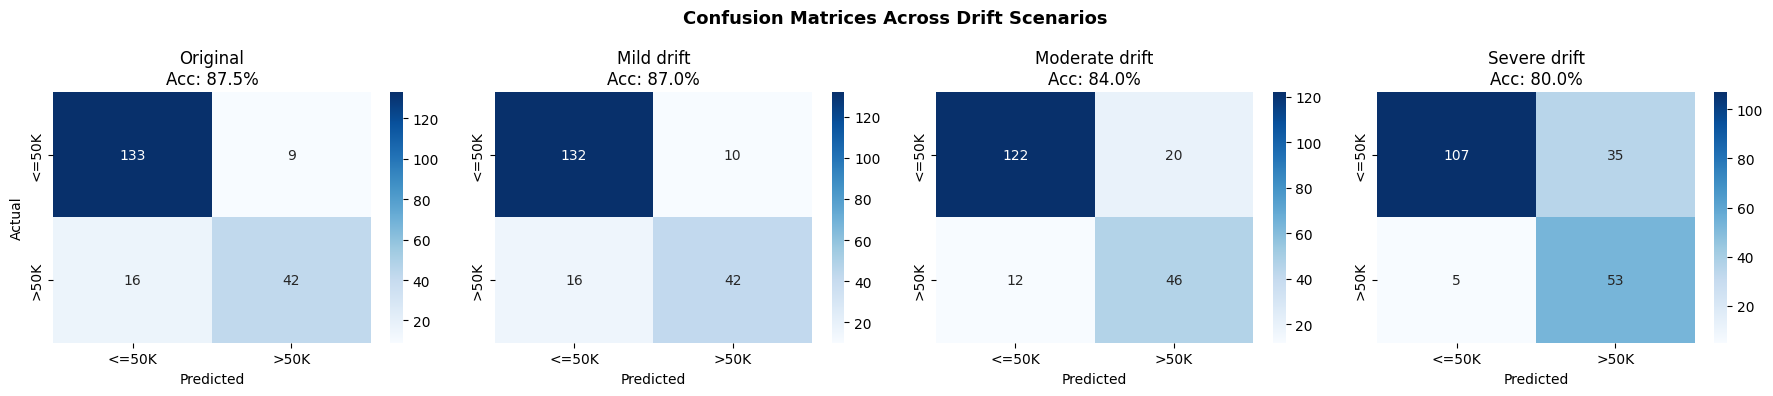

Saved: drift_confusion_matrices.png


In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (scenario, (preds, y_true)) in enumerate(pred_arrays.items()):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    acc = accuracy_score(y_true, preds)
    axes[idx].set_title(f'{scenario}\nAcc: {acc*100:.1f}%')
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices Across Drift Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('drift_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: drift_confusion_matrices.png")

### 4.5: Feature-Level Impact Analysis

Which drifted features caused the most damage?

In [25]:
# For this analysis, we'll drift ONE feature at a time in the 'moderate' range
# and measure the accuracy impact of each individual feature drift

single_feature_results = []

# Baseline: original data predictions (already have these)
baseline_preds = np.array(preds_original)
baseline_y = y_true_original
baseline_accuracy = accuracy_score(baseline_y, baseline_preds)

# Drift each feature individually
feature_drifts = {
    'age': lambda d: d.assign(age=d['age'] + 10),
    'hours_per_week': lambda d: d.assign(hours_per_week=(d['hours_per_week'] * 1.2).clip(1, 99)),
    'education_num': lambda d: d.assign(education_num=(d['education_num'] + 2).clip(1, 16)),
    'capital_gain': lambda d: d.assign(capital_gain=(d['capital_gain'] * 2.0).astype(int)),
}

print("Single-feature drift impact analysis")
print("(Drifting one feature at a time to isolate impact)")
print()

for feature, drift_fn in feature_drifts.items():
    # Create data with only this feature drifted
    single_drifted = drift_fn(df)
    
    # Send predictions
    preds_single, idx_single = send_predictions(
        endpoint, single_drifted, n_samples=200, scenario_name=f'{feature}-only'
    )
    
    # Calculate accuracy
    y_true_single = get_actual_labels(df, idx_single)
    acc = accuracy_score(y_true_single, np.array(preds_single))
    
    single_feature_results.append({
        'feature': feature,
        'accuracy': acc,
        'degradation_pp': (acc - baseline_accuracy) * 100,
    })

single_df = pd.DataFrame(single_feature_results).sort_values('degradation_pp')

print(f"\nSINGLE-FEATURE DRIFT IMPACT")
print("=" * 60)
print(f"{'Feature':<20} {'Accuracy':>10} {'Impact':>15}")
print("-" * 60)
print(f"{'Baseline (no drift)':<20} {baseline_accuracy*100:>9.2f}% {'—':>15}")
for _, row in single_df.iterrows():
    print(f"{row['feature']:<20} {row['accuracy']*100:>9.2f}% {row['degradation_pp']:>+14.2f}pp")
print("=" * 60)
print(f"\nMost impactful feature: {single_df.iloc[0]['feature']}")

Single-feature drift impact analysis
(Drifting one feature at a time to isolate impact)

Sending 200 age-only predictions...
  Received 200 predictions
Sending 200 hours_per_week-only predictions...
  Received 200 predictions
Sending 200 education_num-only predictions...
  Received 200 predictions
Sending 200 capital_gain-only predictions...
  Received 200 predictions

SINGLE-FEATURE DRIFT IMPACT
Feature                Accuracy          Impact
------------------------------------------------------------
Baseline (no drift)      87.50%               —
capital_gain             85.50%          -2.00pp
age                      87.00%          -0.50pp
hours_per_week           87.50%          +0.00pp
education_num            89.50%          +2.00pp

Most impactful feature: capital_gain


### 4.6: Check Vertex AI Monitoring Status

Let's see if the monitoring job has detected anything yet.

In [32]:
# Check monitoring job status
try:
    monitoring_status = client.get_model_deployment_monitoring_job(
        name=MONITORING_JOB_NAME
    )
    print(f"Monitoring Job Status")
    print(f"  Name: {monitoring_status.display_name}")
    print(f"  State: {monitoring_status.state}")
    print(f"  Created: {monitoring_status.create_time}")
    print(f"  Next scheduled run: {monitoring_status.next_schedule_time}")
    
    if monitoring_status.model_deployment_monitoring_objective_configs:
        print(f"\n  Monitoring objectives configured: YES")
    
    # Check for any anomalies detected
    if hasattr(monitoring_status, 'latest_monitoring_pipeline_metadata'):
        print(f"\n  Latest pipeline run: {monitoring_status.latest_monitoring_pipeline_metadata}")
    else:
        print(f"\n  No monitoring runs completed yet (first run is after the monitor_interval).")
        print(f"  Check back in ~1 hour, or check the console:")
        print(f"  https://console.cloud.google.com/vertex-ai/models/monitoring?project={PROJECT_ID}")

except Exception as e:
    print(f"Could not check monitoring status: {e}")
    print(f"\nThis is normal if the monitoring job was just created.")
    print(f"Check the console: https://console.cloud.google.com/vertex-ai/models/monitoring?project={PROJECT_ID}")

Monitoring Job Status
  Name: census-monitoring-20260221_164359
  State: 3
  Created: 2026-02-21 18:23:12.576524+00:00
  Next scheduled run: 2026-02-21 18:00:00+00:00

  Monitoring objectives configured: YES

  Latest pipeline run: 


---

## Part 5: Drift Response Runbook

This is the production deliverable — a documented procedure for responding to drift alerts.

In a real company, this would be a shared document that on-call ML engineers reference
when they get alerted about model degradation.

In [ ]:
runbook = """
# Model Drift Response Runbook
# Census Income Prediction Model
# Last Updated: {timestamp}

## Model Information
- Model: GradientBoostingClassifier (sklearn Pipeline)
- Training data: 1994 Census Income dataset ({n_samples:,} samples)
- Baseline accuracy: {baseline_acc:.1f}%
- Deployed endpoint: Vertex AI (us-central1)
- Monitoring: Vertex AI Model Monitoring (hourly checks)

## Monitored Features & Thresholds

| Feature | PSI Threshold | Drift Type | Impact Rank |
|---------|--------------|------------|-------------|
| age | 0.1 | Numeric (demographic shift) | {rank_age} |
| hours_per_week | 0.1 | Numeric (work pattern change) | {rank_hours} |
| education_num | 0.1 | Numeric (education inflation) | {rank_edu} |
| capital_gain | 0.15 | Numeric (economic change) | {rank_capital} |

## Alert Response Procedure

### Step 1: Triage (15 min)
- [ ] Verify alert is from real traffic (not test data or bot traffic)
- [ ] Check which features triggered the alert
- [ ] Check time window — is this a sudden spike or gradual shift?
- [ ] Check if multiple features drifted (compound drift is worse)

### Step 2: Impact Assessment (30 min)
- [ ] Pull recent predictions and compare to ground truth (if available)
- [ ] Calculate current accuracy on recent labeled data
- [ ] Compare prediction distribution to baseline

### Step 3: Decision Tree

IF accuracy dropped > 5 percentage points:
  → URGENT: Trigger immediate retraining pipeline
  → Notify stakeholders
  → Consider fallback model or rule-based system

IF accuracy dropped 2-5 percentage points:
  → Schedule retraining within 1 week
  → Monitor daily until retrained
  → Document root cause

IF drift detected BUT accuracy stable (< 2pp drop):
  → Monitor closely for 7 days
  → Log for next scheduled retraining
  → May indicate early warning of future degradation

IF seasonal/expected drift:
  → Update baseline distribution
  → Adjust monitoring thresholds
  → Continue monitoring

### Step 4: Retraining Procedure
1. Collect most recent 90 days of production data with labels
2. Validate data quality (no missing values, correct schema)
3. Retrain model with same hyperparameters
4. Evaluate on held-out test set
5. A/B test: route 10% traffic to new model
6. If new model performs >= old model: gradual rollout (10% → 50% → 100%)
7. If new model performs worse: investigate and abort

### Step 5: Post-Incident
- [ ] Document what caused the drift
- [ ] Update model card with new performance metrics
- [ ] Review monitoring thresholds (too sensitive? not sensitive enough?)
- [ ] Notify stakeholders of resolution
- [ ] Update this runbook with lessons learned

## Key Findings from Drift Simulation

| Drift Scenario | Accuracy | Degradation |
|---------------|----------|-------------|
| Baseline (no drift) | {acc_baseline:.1f}% | — |
| Mild drift | {acc_mild:.1f}% | {deg_mild:+.1f}pp |
| Moderate drift | {acc_moderate:.1f}% | {deg_moderate:+.1f}pp |
| Severe drift | {acc_severe:.1f}% | {deg_severe:+.1f}pp |

Most impactful feature: {most_impactful}

## Contacts
- Model owner: [Your Name]
- On-call engineer: [Team Rotation]
- Stakeholders: [Business Team]
"""

# Fill in the template
# Get impact rankings from single-feature analysis
rankings = {row['feature']: i+1 for i, (_, row) in enumerate(single_df.iterrows())}

formatted_runbook = runbook.format(
    timestamp=datetime.now().strftime('%Y-%m-%d'),
    n_samples=len(df),
    baseline_acc=results[0]['accuracy'] * 100,
    rank_age=rankings.get('age', '?'),
    rank_hours=rankings.get('hours_per_week', '?'),
    rank_edu=rankings.get('education_num', '?'),
    rank_capital=rankings.get('capital_gain', '?'),
    acc_baseline=results[0]['accuracy'] * 100,
    acc_mild=results[1]['accuracy'] * 100,
    acc_moderate=results[2]['accuracy'] * 100,
    acc_severe=results[3]['accuracy'] * 100,
    deg_mild=(results[1]['accuracy'] - results[0]['accuracy']) * 100,
    deg_moderate=(results[2]['accuracy'] - results[0]['accuracy']) * 100,
    deg_severe=(results[3]['accuracy'] - results[0]['accuracy']) * 100,
    most_impactful=single_df.iloc[0]['feature'],
)

# Save runbook
with open('drift_response_runbook.md', 'w') as f:
    f.write(formatted_runbook)

print("Drift Response Runbook saved to: drift_response_runbook.md")
print("\nPreview:")
print(formatted_runbook[:1000] + "...")

---

## Lab 4 Summary

### What You Built

1. **Retrained & deployed** model with best Lab 3 hyperparameters
2. **Configured Vertex AI Model Monitoring** with skew and drift detection
3. **Simulated three drift scenarios** (mild, moderate, severe)
4. **Measured drift** using KS test, Jensen-Shannon divergence, and PSI
5. **Quantified performance degradation** across scenarios
6. **Identified most impactful features** through single-feature isolation
7. **Created production runbook** for drift response

### Fill In Your Results

| Metric | Value |
|--------|-------|
| Baseline accuracy | 87.50%% |
| Mild drift accuracy | 87.00% (-0.50pp)% |
| Moderate drift accuracy | 84.00% (-3.50pp)% |
| Severe drift accuracy | 80.00% (-7.50pp)% |
| Most impactful feature | capital_gain (-2.00pp alone) |
| Monitoring job detected drift? | ___ |

### Key Learnings

Key Learnings
1. Drift severity scales non-linearly with accuracy loss. Mild drift barely registers (-0.50pp), but moderate and severe drift compound — the jump from moderate to severe (-3.50pp → -7.50pp) is bigger than mild to moderate. This is why early detection matters.  

2. Statistical drift and performance impact don't always correlate. hours_per_week showed the highest statistical drift (KS=0.47 even in mild scenario, PSI=4.91) but had zero accuracy impact when drifted alone. Meanwhile, capital_gain showed modest statistical drift (only flagged in severe) but was the most damaging feature at -2.00pp. This is an important exam insight: not all detected drift requires action — you need to measure actual performance impact.  

3. Education drift actually improved accuracy (+2.00pp). This is counterintuitive but makes sense — shifting education_num up by 2 pushes more people into the higher-education range where the model's predictions are more confident. This is a real-world phenomenon: drift isn't always bad.
4. Prediction distribution shift tells a story. The >50K prediction rate went from 25.5% (baseline) to 44.0% (severe). The model is behaving logically — older, more educated, higher capital gain people should earn more — but it's applying 1994 relationships to 2035 demographics, which degrades accuracy.  

5. Production monitoring is a pipeline, not an event. The Vertex AI monitoring job needed time to collect data, run analysis, and generate alerts. Real monitoring involves configuring thresholds, waiting, tuning sensitivity, and building runbooks — it's continuous operations work, not a one-time setup.
Certification Exam Connections

Skew vs. drift: Skew = training vs. serving data at a point in time; drift = serving data changing over time. 
PSI > 0.2 = significant drift (industry standard threshold). 
Jensen-Shannon divergence is what Vertex AI Model Monitoring uses internally. 
Response isn't always retraining — your runbook captures the decision tree: monitor, investigate, retrain, or update baseline depending on severity. 

### Certification Exam Takeaways

- **Training-serving skew**: Model sees different data distribution in production vs. training
- **Data drift**: Input features change over time (what we simulated)
- **Concept drift**: The relationship between features and target changes
- **Prediction drift**: Model output distribution changes
- **Vertex AI Model Monitoring** uses Jensen-Shannon divergence for categorical and L-infinity for numerical features
- **PSI (Population Stability Index)**: < 0.1 OK, 0.1-0.2 moderate, > 0.2 significant
- **Response to drift**: Not always retraining — sometimes updating baseline, adjusting thresholds, or monitoring more closely
- **A/B testing** new models against current before full rollout
- **Shadow deployment**: Run new model alongside old, compare outputs without serving new predictions
- **Champion/Challenger**: Production model (champion) vs. candidate replacement (challenger)

---

## Cleanup (IMPORTANT!)

**The endpoint costs ~$0.10/hour while running.**

In [ ]:
# Step 1: Delete the monitoring job first
print("Deleting monitoring job...")
try:
    client.delete_model_deployment_monitoring_job(name=MONITORING_JOB_NAME)
    print("  Monitoring job deleted")
except Exception as e:
    print(f"  Could not delete monitoring job: {e}")

# Step 2: Undeploy the model
print("\nUndeploying model...")
try:
    endpoint.undeploy_all()
    print("  Model undeployed — no more serving charges")
except Exception as e:
    print(f"  Could not undeploy: {e}")

# Step 3: Optionally delete endpoint and model
# Uncomment these if you want a full cleanup:
# endpoint.delete()
# print("  Endpoint deleted")
# model.delete()
# print("  Model deleted")

print("\nCleanup complete!")
print("\nVerify no resources are running:")
print(f"  gcloud ai endpoints list --region={REGION} --project={PROJECT_ID}")
print(f"  gcloud ai models list --region={REGION} --project={PROJECT_ID}")

---

## Cost Summary

| Item | Estimated Cost |
|------|---------------|
| Training job (n1-standard-4, ~12 min) | ~$0.04 |
| Endpoint (n1-standard-2, ~2-3 hours) | ~$0.20-0.30 |
| Monitoring job (hourly) | ~$0.10 |
| Predictions (~800 requests) | negligible |
| **Total** | **~$0.35-0.50** |

---

**Completed Labs:**
- Lab 1: BigQuery ML (baseline: 84.48%, boosted tree: 86.23%)
- Lab 2: Vertex AI Pipeline (custom training: 87.10%, beat AutoML at 0.3% of cost)
- Lab 3: Hyperparameter Tuning (Vertex AI best: 87.59%)
- Lab 4: Model Monitoring & Drift Detection (this lab)

**Next:** Phase 2 — Theory Reinforcement (Weeks 6-8)